
Processing Model: Fornax
   [ROOT] Saved TH2D and TH1D to supernova_data_Fornax.root
   [Check] Total weight sum for Fornax: 1.00
   [JSON] Created: config_Fornax_No_Oscillations.js


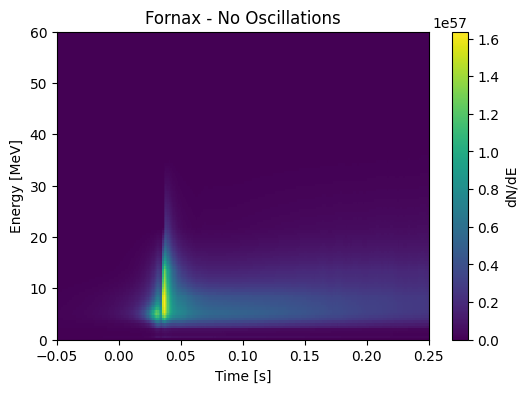

   [ROOT] Saved TH2D and TH1D to supernova_data_Fornax.root
   [Check] Total weight sum for Fornax: 1.00
   [JSON] Created: config_Fornax_Normal_Hierarchy.js


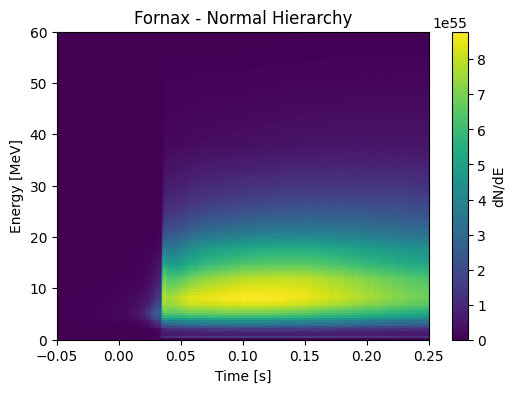

   [ROOT] Saved TH2D and TH1D to supernova_data_Fornax.root
   [Check] Total weight sum for Fornax: 1.00
   [JSON] Created: config_Fornax_Inverted_Hierarchy.js


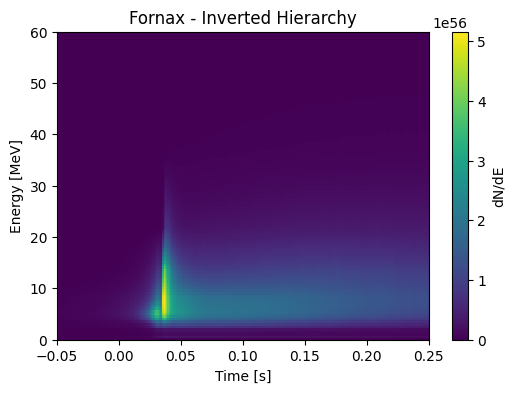


Processing Model: Sukhbold
   [ROOT] Saved TH2D and TH1D to supernova_data_Sukhbold.root
   [Check] Total weight sum for Sukhbold: 1.00
   [JSON] Created: config_Sukhbold_No_Oscillations.js


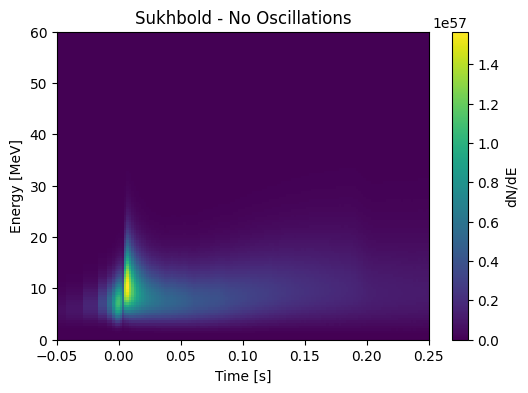

   [ROOT] Saved TH2D and TH1D to supernova_data_Sukhbold.root
   [Check] Total weight sum for Sukhbold: 1.00
   [JSON] Created: config_Sukhbold_Normal_Hierarchy.js


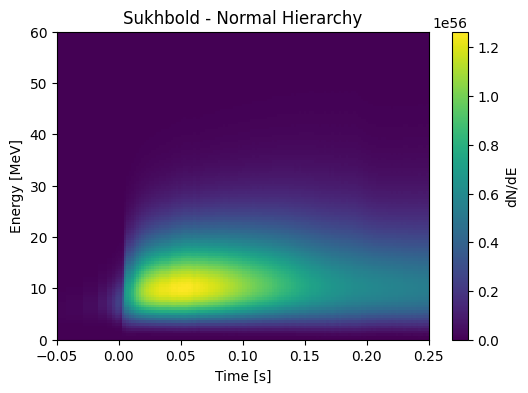

   [ROOT] Saved TH2D and TH1D to supernova_data_Sukhbold.root
   [Check] Total weight sum for Sukhbold: 1.00
   [JSON] Created: config_Sukhbold_Inverted_Hierarchy.js


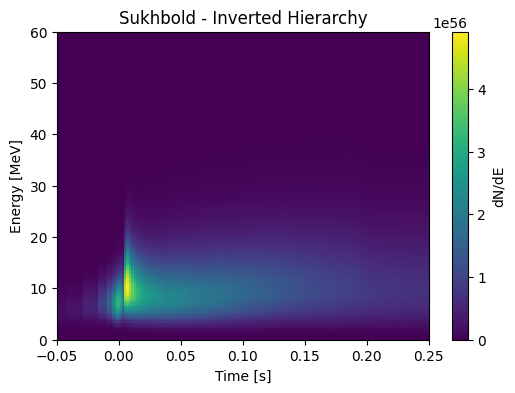

In [22]:
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ROOT
import array
from snewpy.models.ccsn import Nakazato_2013, Bollig_2016, Fornax_2021, Sukhbold_2015
from snewpy.neutrino import Flavor, MassHierarchy
from snewpy.flavor_transformation import NoTransformation, AdiabaticMSW

# Use np.trapezoid for newer numpy versions
if not hasattr(np, 'trapz'):
    np.trapz = np.trapezoid

# --- MARLEY Configuration Writer ---
def write_marley_config(model_name, label, energies, weights, e_max):
    """Writes a MARLEY-compatible .js file with area-normalized weights."""
    filename = f"config_{model_name}_{label.replace(' ', '_')}.js"
    
    # Format energies (11 per line for readability)
    e_str = ""
    for i in range(0, len(energies), 11):
        chunk = [f"{e:4.1f}" for e in energies[i:i+11]]
        e_str += "        " + ", ".join(chunk) + ",\n"
    e_str = e_str.rstrip(",\n")

    # Format weights (4 per line, NO '+' in exponent for MARLEY parser)
    w_str = ""
    for i in range(0, len(weights), 4):
        chunk = [f"{w:.9e}".replace("e+", "e") for w in weights[i:i+4]]
        w_str += "       " + ", ".join(chunk) + ",\n"
    w_str = w_str.rstrip(",\n")

    config_text = f"""// MARLEY Configuration for {model_name} - {label}
{{
  seed: 123456,
  reactions: [ "ve40ArCC_Bhattacharya2009.react" ],
  source: {{
    type: "histogram",
    neutrino: "ve",
    E_bin_lefts: [
{e_str}
    ],
    weights: [
{w_str}
    ],
    Emax: {e_max:.1f},
  }},
  direction: {{ x: 0.0, y: -1.0, z: 0.0 }},
}}"""
    with open(filename, "w") as f:
        f.write(config_text)
    print(f"   [JSON] Created: {filename}")

# --- Initialize Supernova Models ---
#nakazato = Nakazato_2013(progenitor_mass=20 * u.solMass,revival_time=100 * u.ms,metallicity=0.004,eos='shen')
#bollig = Bollig_2016(progenitor_mass=27 * u.solMass)

fornax = Fornax_2021(progenitor_mass=25*u.solMass)

sukhbold = Sukhbold_2015(progenitor_mass=27*u.solMass, eos='LS220')

#Add to models function if you want to include the Bollig and Nakazato models in the loop. They are currently excluded to focus on the new Fornax and Sukhbold models.

models = {"Fornax": fornax, "Sukhbold": sukhbold}



 # --- Define Neutrino Oscillation Scenarios ---

transforms = {

"No Oscillations": NoTransformation(),

"Normal Hierarchy": AdiabaticMSW(mh=MassHierarchy.NORMAL),

"Inverted Hierarchy": AdiabaticMSW(mh=MassHierarchy.INVERTED)

} 


# --- Global Setup ---
E_bins = np.linspace(0, 100, 200) * u.MeV
E_centers = (E_bins[:-1] + E_bins[1:]) / 2
flavor = Flavor.NU_E

# --- Main Processing Loop ---
for model_name, model in models.items():
    print(f"\nProcessing Model: {model_name}")
    times = model.time.to_value(u.s)

    for label, transform in transforms.items():
        # Get spectra (shape: time x energy)
        spectra = model.get_transformed_spectra(model.time, E_bins, transform)
        spec_nue = spectra[flavor].to_value(1 / (u.s * u.MeV))
        spec_nue = np.clip(spec_nue, 0, None)

       # 1. --- Prepare ROOT File and Buffers ---
        root_file_name = f"supernova_data_{model_name}.root"
        # Open file FIRST so histograms are created in this directory
        tf = ROOT.TFile(root_file_name, "UPDATE") 

        t_edges = times.astype(float)
        e_edges = E_bins.to_value(u.MeV).astype(float)

        x_buffer = array.array('d', t_edges)
        y_buffer = array.array('d', e_edges)

        # 2. --- 2D Spectrum TH2D ---
        hist_2d_name = f"h2d_{model_name}_{label.replace(' ', '_')}"
        
        # Create TH2D
        h2d = ROOT.TH2D(
            hist_2d_name, 
            f"{model_name} {label};Time [s];Energy [MeV]", 
            len(x_buffer)-1, x_buffer, 
            len(y_buffer)-1, y_buffer
        )

        # Dimension Check: ROOT expects data for (nbinsX * nbinsY)
        # spec_nue shape must be (len(t_edges)-1, len(e_edges)-1)
        ntime, nenergy = spec_nue.shape
        
        # We use min() to prevent index out of bounds if shapes slightly mismatch
        for i in range(min(ntime, len(x_buffer)-1)):
            for j in range(min(nenergy, len(y_buffer)-1)):
                h2d.SetBinContent(i + 1, j + 1, float(spec_nue[i, j]))

        # 3. --- 1D Time-Integrated TH1D ---
        # Integrate over time to get dN/dE
        counts_vs_energy = np.trapz(spec_nue, x=times, axis=0)
        counts_vs_energy = np.clip(counts_vs_energy, 0, None)   # ← add this to ensure no negative values
        
        # Ensure 1D data matches 1D bin count
        if len(counts_vs_energy) >= len(y_buffer):
            counts_vs_energy = counts_vs_energy[:len(y_buffer)-1]

        hist_1d_name = f"h1d_{model_name}_{label.replace(' ', '_')}"
        th1 = ROOT.TH1D(
            hist_1d_name,
            f"{model_name} Time-Integrated;Energy [MeV];Counts",
            len(y_buffer)-1, y_buffer
        )

        for i, val in enumerate(counts_vs_energy):
            th1.SetBinContent(i + 1, float(val))
        
        # Final Write and Close
        h2d.Write("", ROOT.TObject.kOverwrite)
        th1.Write("", ROOT.TObject.kOverwrite)
        tf.Close()
        
        print(f"   [ROOT] Saved TH2D and TH1D to {root_file_name}")

        # 3. --- Area-Normalized MARLEY Config ---
        total_integral = np.sum(counts_vs_energy)
        if total_integral > 0:
            area_norm_weights = counts_vs_energy / total_integral
        else:
            area_norm_weights = counts_vs_energy
            
        # Debug print to satisfy advisor's requirement
        print(f"   [Check] Total weight sum for {model_name}: {np.sum(area_norm_weights):.2f}")

        energies_left = e_edges[:-1]
        e_max_val = e_edges[-1]
        write_marley_config(model_name, label, energies_left, area_norm_weights, e_max_val)

        # 4. --- Matplotlib Plotting (Optional Visual) ---
        plt.figure(figsize=(6, 4))
        plt.pcolormesh(times, e_edges, spec_nue.T, shading='auto')
        plt.title(f"{model_name} - {label}")
        plt.xlabel("Time [s]")
        plt.ylabel("Energy [MeV]")
        plt.colorbar(label="dN/dE")
        plt.xlim(-0.05, 0.25)
        plt.ylim(0, 60)
        plt.show()

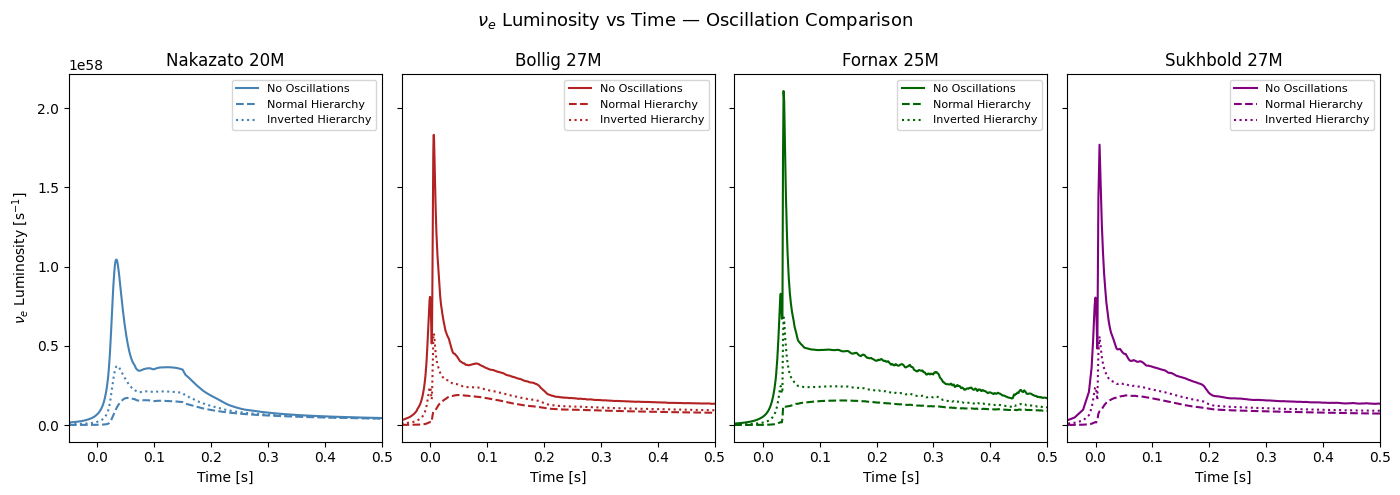

In [5]:
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from snewpy.models.ccsn import Nakazato_2013, Bollig_2016, Fornax_2021, Sukhbold_2015,OConnor_2013
from snewpy.neutrino import Flavor, MassHierarchy
from snewpy.flavor_transformation import NoTransformation, AdiabaticMSW

# --- Models ---
models = {
    "Nakazato 20M": Nakazato_2013(progenitor_mass=20*u.solMass, revival_time=100*u.ms, metallicity=0.004, eos='shen'),
    "Bollig 27M":   Bollig_2016(progenitor_mass=27*u.solMass),
    "Fornax 25M": Fornax_2021(progenitor_mass=25*u.solMass),
    "Sukhbold 27M": Sukhbold_2015(progenitor_mass=27*u.solMass, eos='LS220'),
    "OConnor 20M": OConnor_2013(progenitor_mass=20*u.solMass, eos='LS220')
}

# --- Oscillation schemes ---
transforms = {
    "No Oscillations":    NoTransformation(),
    "Normal Hierarchy":   AdiabaticMSW(mh=MassHierarchy.NORMAL),
    "Inverted Hierarchy": AdiabaticMSW(mh=MassHierarchy.INVERTED)
}

E_bins = np.linspace(0, 100, 200) * u.MeV

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)
linestyles = {"No Oscillations": "-", "Normal Hierarchy": "--", "Inverted Hierarchy": ":"}
colors     = {"Nakazato 20M": "steelblue", "Bollig 27M": "firebrick", "Fornax 25M": "darkgreen", "Sukhbold 27M": "purple"} #"OConnor 20M": "orange"}

for ax, (model_name, model) in zip(axes, models.items()):
    times = model.time.to(u.s)

    for label, transform in transforms.items():
        spectra  = model.get_transformed_spectra(times, E_bins, transform)
        spec_nue = spectra[Flavor.NU_E].to(1 / (u.s * u.MeV))

        # Integrate over energy → luminosity spectrum L(t) [s⁻¹]
        luminosity = np.trapezoid(spec_nue, x=E_bins, axis=1)

        ax.plot(times.to_value(u.s), luminosity.to_value(1/u.s),
                linestyle=linestyles[label],
                color=colors[model_name],
                label=label)

    ax.set_title(model_name)
    ax.set_xlabel("Time [s]")
    ax.set_xlim(-0.05, 0.5)
    #ax.set_ylim(1e53, 1e59)  # Adjust as needed for better visualization
    #ax.set_yscale("log")
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"$\nu_e$ Luminosity [s$^{-1}$]")
fig.suptitle(r"$\nu_e$ Luminosity vs Time — Oscillation Comparison", fontsize=13)
plt.tight_layout()
plt.show()